# Task 4 - Classification Models, Evaluation Metrics & Handling Imbalanced Data

In this task we move from regression to classification. We will predict whether a
customer will churn (leave the service) or not, using the Telco Customer Churn dataset.

Steps:
1. Import libraries
2. Load and prepare dataset
3. Train-test split
4. Feature scaling
5. Train baseline Logistic Regression model
6. Confusion matrix and classification report
7. Precision, recall, F1-score interpretation
8. ROC curve and AUC score
9. Handle class imbalance using class_weight
10. Compare with Decision Tree Classifier


In [7]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

print("Libraries imported")


Libraries imported


## Step 2: Load Dataset

Using the Telco Customer Churn dataset uploaded as `WA_Fn-UseC_-Telco-Customer-Churn.csv`.

Target column: `Churn` (Yes/No)


In [8]:
# Step 2: Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Step 3: Basic Cleaning

`customerID` is not useful for prediction so we drop it. `TotalCharges` has some
blank values (for customers with 0 tenure) so we convert it to numeric and fill
missing values with 0.


In [10]:
# Step 3: Basic Cleaning
df = df.drop("customerID", axis=1)

# TotalCharges has some blank strings, convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing values:")
print(df.isnull().sum().sum())


Missing values:
0


## Step 4: Check Class Balance

Before doing anything else, let's check how balanced the target classes are.


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


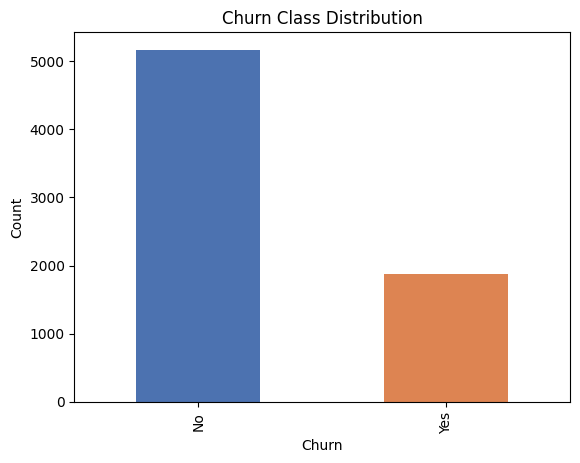

In [11]:
# Step 4: Check Class Balance
print(df["Churn"].value_counts())
print()
print(df["Churn"].value_counts(normalize=True) * 100)

df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


We can see the classes are imbalanced. Most customers did not churn, so a model
that just predicts "No" every time would still get decent accuracy. This is exactly
why accuracy alone is not a good metric here.


## Step 5: Encode Categorical Columns

Most columns in this dataset are categorical (Yes/No, or service type). We use
one-hot encoding for the feature columns and label encode the target.


In [12]:
# Step 5: Encode Categorical Columns
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
y = df["Churn"]

print("Features shape:", X.shape)
X.head()


Features shape: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## Step 6: Train-Test Split

We use `stratify=y` so the train and test sets keep the same churn ratio as the
full dataset.


In [13]:
# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Churn rate in train:", y_train.mean().round(3))
print("Churn rate in test:", y_test.mean().round(3))


Train rows: 5634
Test rows: 1409
Churn rate in train: 0.265
Churn rate in test: 0.265


## Step 7: Feature Scaling


In [14]:
# Step 7: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done")


Scaling done


## Step 8: Train Baseline Classification Model (Logistic Regression)


In [15]:
# Step 8: Train Baseline Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))


Accuracy: 0.807


## Step 9: Confusion Matrix & Classification Report

The confusion matrix tells us:
- **True Positives (TP)**: correctly predicted churn
- **True Negatives (TN)**: correctly predicted no churn
- **False Positives (FP)**: predicted churn but customer stayed
- **False Negatives (FN)**: predicted no churn but customer actually left

For churn prediction, **False Negatives are the costly mistake** since we miss a
customer who was about to leave and don't get a chance to retain them.


Confusion Matrix:
[[925 110]
 [162 212]]


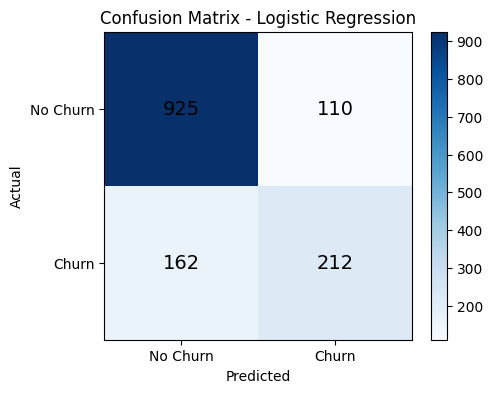

In [16]:
# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
plt.show()


In [17]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Why accuracy alone is not enough

Since most customers do not churn, a model could get high accuracy just by
predicting "No Churn" most of the time, without actually being useful. Precision
and recall give a clearer picture of how well the model finds the customers who
actually churn.

- **Precision** answers: of all customers we predicted would churn, how many actually did?
- **Recall** answers: of all customers who actually churned, how many did we catch?
- **F1-score** balances precision and recall into one number, useful when classes
  are imbalanced like here.

If recall is low, it means we are missing a lot of customers who are about to
churn, which is a real business cost since we don't get a chance to offer them
a retention deal.


## Step 10: ROC Curve & AUC Score

The ROC curve shows the tradeoff between True Positive Rate and False Positive
Rate at different thresholds. AUC (Area Under Curve) summarizes this into a
single number - closer to 1 is better, 0.5 means the model is no better than
random guessing.


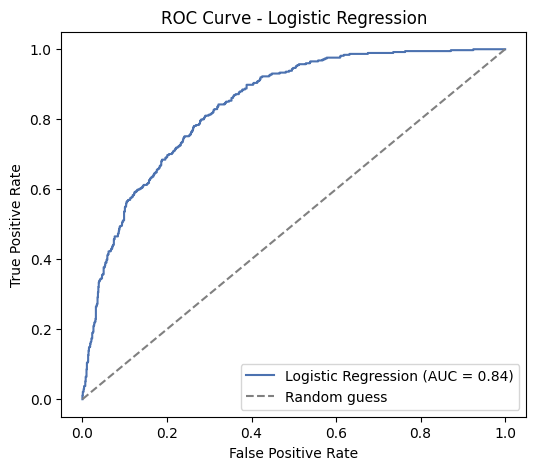

AUC Score: 0.8418


In [18]:
# Step 10: ROC Curve & AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})", color="#4C72B0")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", round(auc, 4))


## Step 11: Handle Class Imbalance

We try `class_weight="balanced"` which makes the model pay more attention to
the minority class (churned customers) instead of treating both classes equally.


In [19]:
# Step 11: Logistic Regression with class_weight balanced
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Baseline Logistic Regression:")
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

print("Logistic Regression with class_weight='balanced':")
print(classification_report(y_test, y_pred_balanced, target_names=["No Churn", "Churn"]))


Baseline Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Logistic Regression with class_weight='balanced':
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



With `class_weight="balanced"`, recall for the churn class usually goes up
because the model is now penalized more for missing churn cases, but this often
comes with some drop in precision. This is the classic precision-recall tradeoff.


## Step 12: Compare with Decision Tree Classifier


In [20]:
# Step 12: Decision Tree Classifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree Classifier:")
print(classification_report(y_test, y_pred_tree, target_names=["No Churn", "Churn"]))

train_acc = accuracy_score(y_train, tree.predict(X_train))
test_acc = accuracy_score(y_test, y_pred_tree)
print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))


Decision Tree Classifier:
              precision    recall  f1-score   support

    No Churn       0.81      0.82      0.81      1035
       Churn       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409

Train Accuracy: 0.998
Test Accuracy: 0.726


### Logistic Regression vs Decision Tree

- Logistic Regression is more stable and easier to interpret using coefficients.
- Decision Tree can overfit easily, which we can see if train accuracy is a lot
  higher than test accuracy.
- Logistic Regression generally performed more consistently here, while the
  Decision Tree shows signs of overfitting on the training data.


## Step 13: Model Comparison Summary


In [21]:
# Step 13: Model Comparison Table
from sklearn.metrics import precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

results = pd.DataFrame({
    "Logistic Regression": get_metrics(y_test, y_pred),
    "Logistic Regression (balanced)": get_metrics(y_test, y_pred_balanced),
    "Decision Tree": get_metrics(y_test, y_pred_tree)
}).T

results["AUC"] = [
    roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, model_balanced.predict_proba(X_test_scaled)[:, 1]),
    roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])
]

results.round(4)


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.8070,0.6584,0.5668,0.6092,0.8418
Logistic Regression (balanced),0.7402,0.5069,0.7861,0.6164,0.8414
Decision Tree,0.7260,0.4838,0.4786,0.4812,0.6465


## Step 14: Final Notes

- The dataset is imbalanced (more "No Churn" than "Churn" customers), so
  accuracy alone was not a reliable metric.
- Precision, Recall, F1-score, and AUC gave a better picture of how each model
  actually performs on the churn class.
- Using `class_weight="balanced"` helped improve recall for the churn class at
  some cost to precision.
- Decision Tree showed more overfitting compared to Logistic Regression.
- For a churn use case, recall on the churn class is usually more important
  since missing a customer who is about to leave is more costly than a false
  alarm.
